# 🎮 Gaming Behavior & CGPA Prediction


## Import All Libraries

In [ ]:
# ── Core ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
try:
    import missingno as msno
    MISSINGNO = True
except ImportError:
    MISSINGNO = False
    print("missingno not installed — skipping missing-value visual (pip install missingno)")

# ── Preprocessing ─────────────────────────────────────────────────────
from sklearn.preprocessing import (
    LabelEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_val_score, GridSearchCV, RandomizedSearchCV
)
from sklearn.impute import SimpleImputer

# ── Regression Models ─────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
try:
    from xgboost import XGBRegressor
    XGB_OK = True
except ImportError:
    XGB_OK = False
    print("XGBoost not installed — skipping (pip install xgboost)")
try:
    from lightgbm import LGBMRegressor
    LGB_OK = True
except ImportError:
    LGB_OK = False
    print("LightGBM not installed — skipping (pip install lightgbm)")

# ── Classification Models ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ── Evaluation Metrics ────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, r2_score,
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

# ── Hypothesis Testing ────────────────────────────────────────────────
from scipy import stats
import statsmodels.api as sm

# ── Explainability ────────────────────────────────────────────────────
try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print("SHAP not installed — skipping (pip install shap)")

# ── Persistence ───────────────────────────────────────────────────────
import joblib

# ── Style ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


## Load Dataset & Initial Inspection

In [ ]:
df = pd.read_csv("data.csv")

# Drop unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(f"Dataset Shape : {df.shape}")
print(f"Total Cells   : {df.size}")
print(f"Memory Usage  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.head()

Dataset Shape : (989, 20)
Total Cells   : 19780
Memory Usage  : 748.9 KB


,What is your age?,Current educational position?,Gender?,Your current CGPA?,Your Higher Secondary School(H. SC) or A level or equivalent result?,At what age you had started playing games?,Do you play games on mobile or pc?,When you go to sleep?,Do you attend your morning class regularly?,The average time you spend playing games?,Which type of game you addict more?,Do you read newspaper?,Which type of game you played most?,How many time you spend with family and friend?,How you fill when you can not play game in whole day?,How you fill to complete game level?,If you didn't finish games last level what is your feeling?,Do you fill Fatigue?,Do you play games for stress relief?,Are you wearing glasses?
0,21,Bachelor Level,Male,4.00,5.0,10,"Mobile, PC",2,Yes,4,FIFA,Not regular,Non Paid,3,negative,Excited,Excited to complete level,No,Yes,Yes
1,21,Bachelor Level,Male,3.00,5.0,11,Mobile,2,No,5,FREE FIRE,Not regular,Paid,1,negative,Excited,Excited to complete level,No,Yes,No
2,21,Bachelor Level,Male,3.75,5.0,12,"Mobile, PC",1,Yes,3,FIFA,Not regular,Non Paid,5,negative,Excited,Excited to complete level,No,Yes,Yes
3,20,Bachelor Level,Male,3.50,5.0,18,Mobile,0,Yes,2,FIFA,Not regular,Non Paid,7,positive,Excited,Excited to complete level,Yes,Yes,No
4,25,Bachelor Level,Male,2.00,5.0,14,Mobile,2,No,2,FIFA,Not regular,Non Paid,6,positive,Excited,No feeling,Yes,No,No


##  Data Types & Summary Statistics

In [ ]:
print("=" * 55)
print("COLUMN INFO")
print("=" * 55)
df.info()
print("\n")
print("=" * 55)
print("DESCRIPTIVE STATISTICS")
print("=" * 55)
df.describe(include='all').T

COLUMN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 989 entries, 0 to 988
Data columns (total 20 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   What is your age?                                                     989 non-null    int64  
 1   Current educational position?                                         989 non-null    object 
 2   Gender?                                                               989 non-null    object 
 3   Your  current CGPA?                                                   989 non-null    float64
 4   Your Higher Secondary School(H. SC) or A level or equivalent result?  989 non-null    float64
 5   At what age you had started playing games?                            989 non-null    int64  
 6   Do you play games on mobile or pc?                                    989 non-null    

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
What is your age?,989.0,NaN,NaN,NaN,22.994944,3.162434,18.0,20.0,23.0,26.0,30.0
Current educational position?,989,2,Bachelor Level,679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender?,989,2,Male,499,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Your current CGPA?,989.0,NaN,NaN,NaN,3.130354,0.560888,2.0,2.84,3.02,3.56,4.0
Your Higher Secondary School(H. SC) or A level or equivalent result?,989.0,NaN,NaN,NaN,4.155399,0.657749,2.0,3.81,4.1,4.73,5.0
At what age you had started playing games?,989.0,NaN,NaN,NaN,19.528817,2.570943,3.0,18.0,20.0,21.0,24.0
Do you play games on mobile or pc?,989,3,Mobile,494,NaN,NaN,NaN,NaN,NaN,NaN,NaN
When you go to sleep?,989.0,NaN,NaN,NaN,9.633974,10.511104,0.0,1.0,2.0,22.0,23.0
Do you attend your morning class regularly?,989,2,Yes,503,NaN,NaN,NaN,NaN,NaN,NaN,NaN
The average time you spend playing games?,989.0,NaN,NaN,NaN,3.77452,1.594118,0.0,2.0,4.0,5.0,8.0


##  Missing Value Analysis

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print("✅ No missing values found in the dataset.")
else:
    print(missing_df)
    if MISSINGNO:
        msno.matrix(df)
        plt.title("Missing Value Matrix")
        plt.show()

✅ No missing values found in the dataset.


##  Define Target & Feature Columns

In [ ]:
# Print all column names to confirm the target
print("All columns:")
for i, col in enumerate(df.columns):
    print(f"  [{i:02d}] {repr(col)}")

# ── Set target variable ───────────────────────────────────────────────
TARGET = 'Your  current CGPA?'   # ← adjust if your column name differs

assert TARGET in df.columns, f"Target column '{TARGET}' not found! Check spelling above."
print(f"\n✅ Target column confirmed: {repr(TARGET)}")

All columns:
  [00] 'What is your age?'
  [01] 'Current educational position?'
  [02] 'Gender?'
  [03] 'Your  current CGPA?'
  [04] 'Your Higher Secondary School(H. SC) or A level or equivalent result?'
  [05] 'At what age you had started playing games?'
  [06] 'Do you play games on mobile or pc?'
  [07] 'When you go to sleep?'
  [08] 'Do you attend your morning class regularly?'
  [09] 'The average time you spend playing games?'
  [10] 'Which type of game you addict more?'
  [11] 'Do you read newspaper?'
  [12] 'Which type of game you played most?'
  [13] 'How many time you spend with family and friend?'
  [14] 'How you fill when you can not play game in whole day?'
  [15] 'How you fill to complete game level?'
  [16] "If you didn't finish games last level what is your feeling?"
  [17] 'Do you fill Fatigue?'
  [18] 'Do you play games for stress relief?'
  [19] 'Are you wearing glasses?'

✅ Target column confirmed: 'Your  current CGPA?'


##  Target Variable Distribution (CGPA)

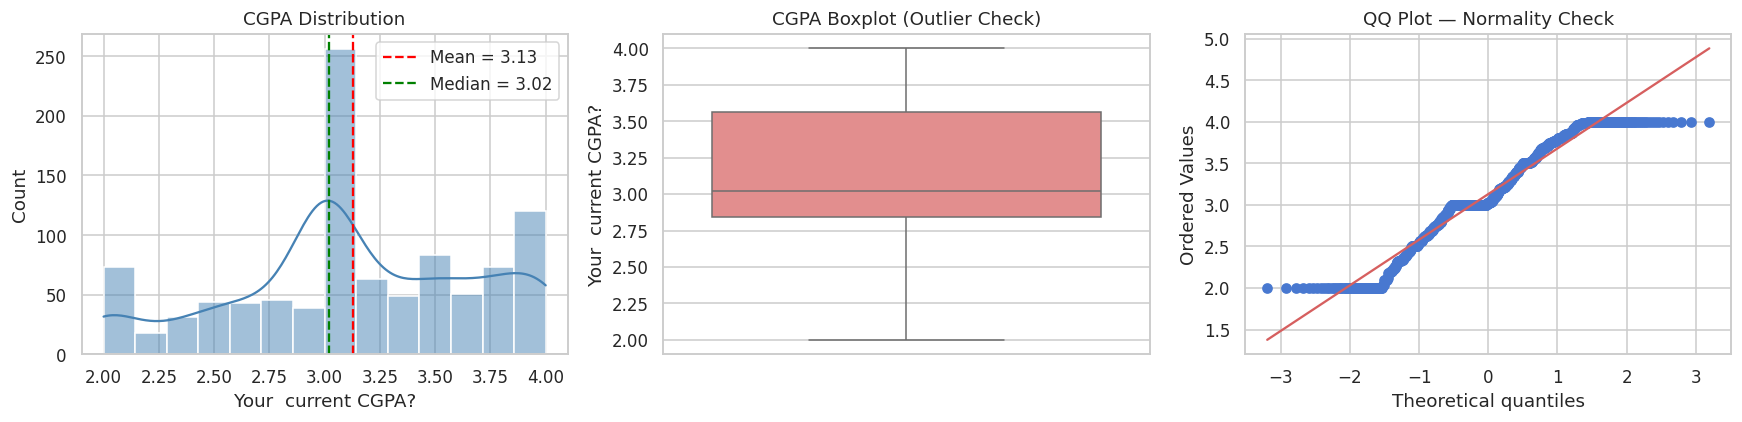

Skewness : -0.2423
Kurtosis : -0.6287
Shapiro-Wilk p-value: 0.0000 → Not Normal distribution


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram + KDE
sns.histplot(df[TARGET], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("CGPA Distribution")
axes[0].axvline(df[TARGET].mean(), color='red', linestyle='--', label=f"Mean = {df[TARGET].mean():.2f}")
axes[0].axvline(df[TARGET].median(), color='green', linestyle='--', label=f"Median = {df[TARGET].median():.2f}")
axes[0].legend()

# Boxplot
sns.boxplot(y=df[TARGET], ax=axes[1], color='lightcoral')
axes[1].set_title("CGPA Boxplot (Outlier Check)")

# QQ Plot (normality check)
stats.probplot(df[TARGET].dropna(), dist="norm", plot=axes[2])
axes[2].set_title("QQ Plot — Normality Check")

plt.tight_layout()
plt.show()

print(f"Skewness : {df[TARGET].skew():.4f}")
print(f"Kurtosis : {df[TARGET].kurt():.4f}")
stat, p = stats.shapiro(df[TARGET].dropna())
print(f"Shapiro-Wilk p-value: {p:.4f} → {'Not Normal' if p < 0.05 else 'Approx Normal'} distribution")

##  Distribution of All Numeric Features

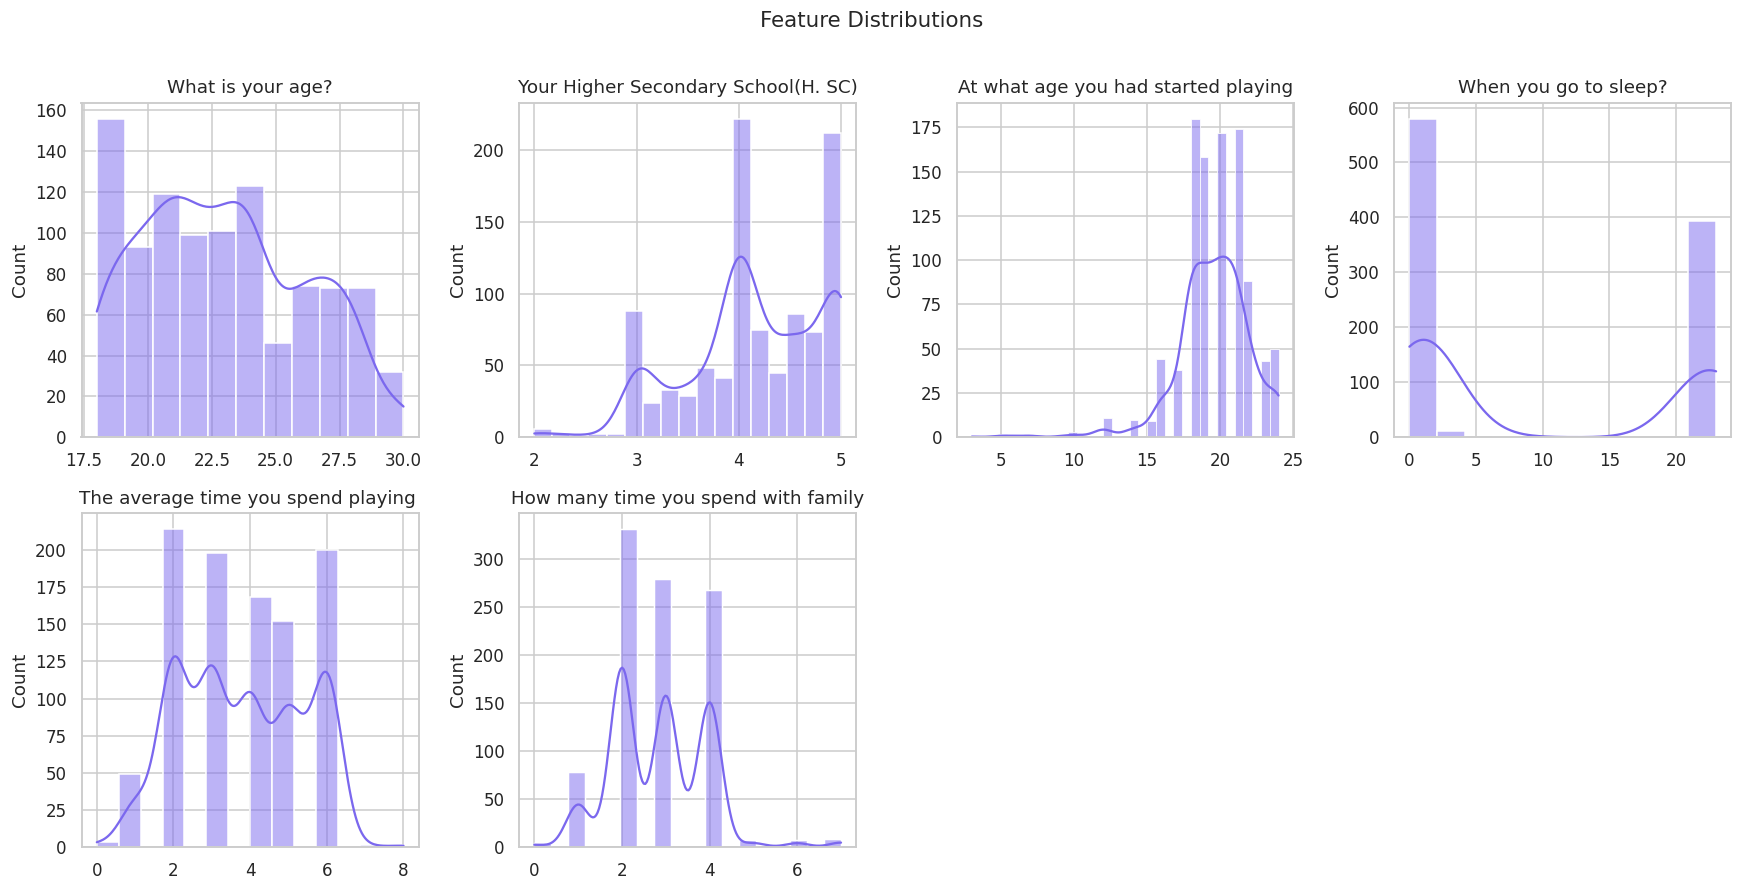

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols_no_target = [c for c in num_cols if c != TARGET]

n = len(num_cols_no_target)
cols_per_row = 4
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols_no_target):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='mediumslateblue')
    axes[i].set_title(col[:35])
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

##  Boxplots (Outlier Detection for All Features)

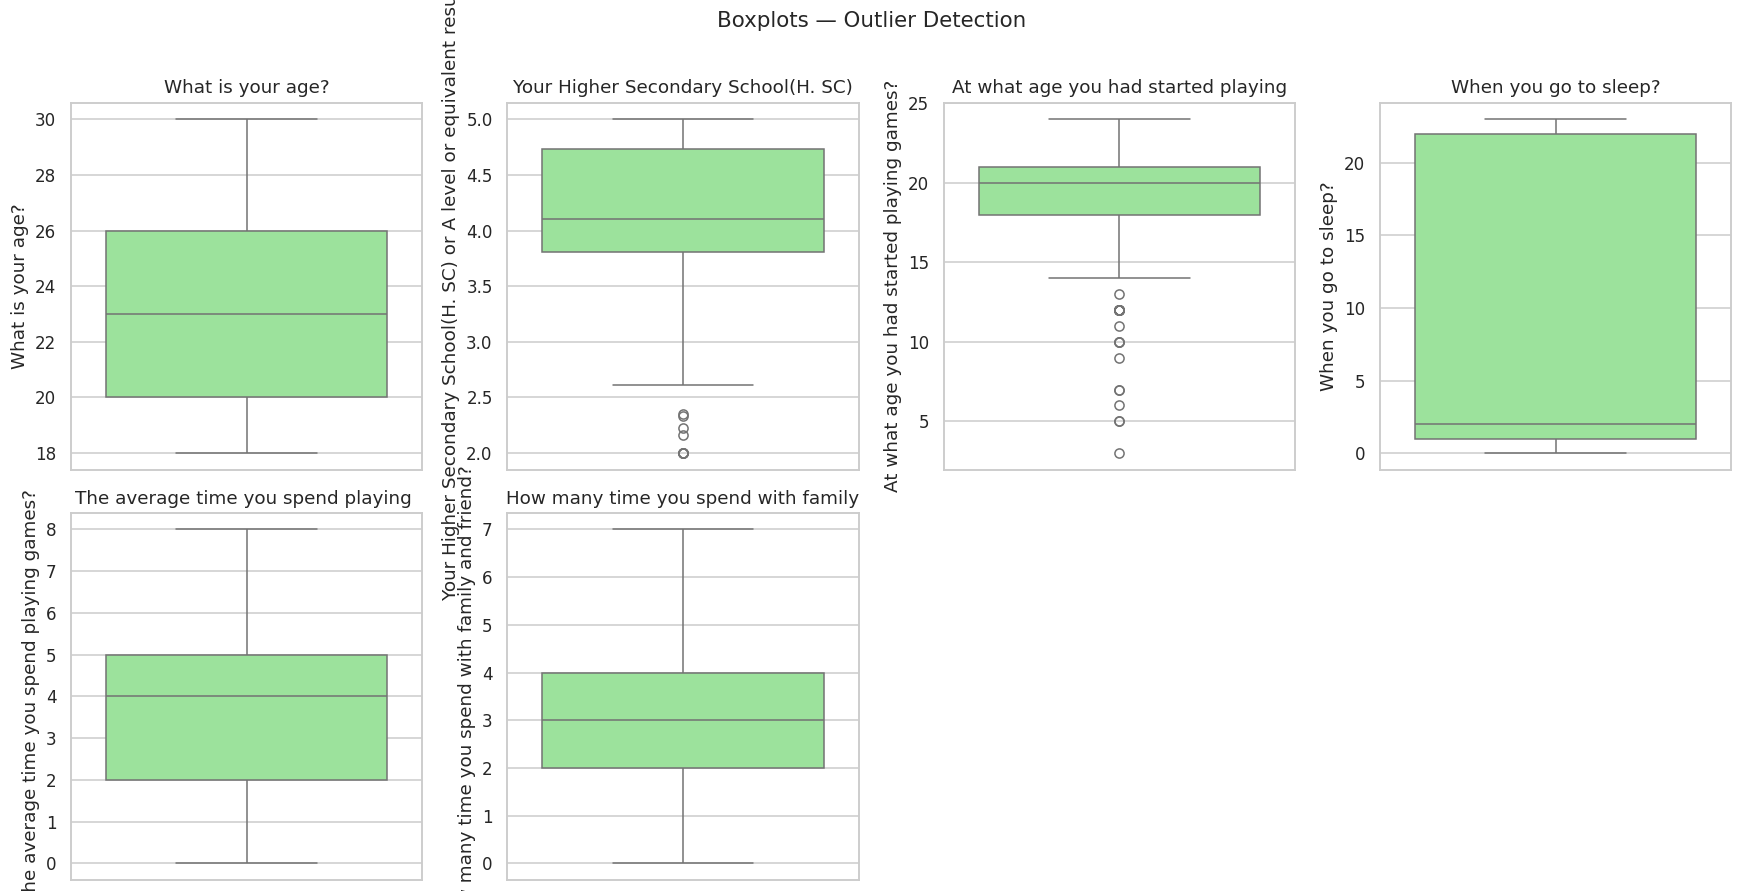


📊 IQR Outlier Count per Column:
  Your Higher Secondary School(H. SC) or A  : 9 outliers
  At what age you had started playing game  : 23 outliers


In [ ]:
fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols_no_target):
    sns.boxplot(y=df[col].dropna(), ax=axes[i], color='lightgreen')
    axes[i].set_title(col[:35])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots — Outlier Detection", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# IQR-based outlier count per column
print("\n📊 IQR Outlier Count per Column:")
for col in num_cols_no_target:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    if len(outliers) > 0:
        print(f"  {col[:40]:<42}: {len(outliers)} outliers")

## Correlation Heatmap

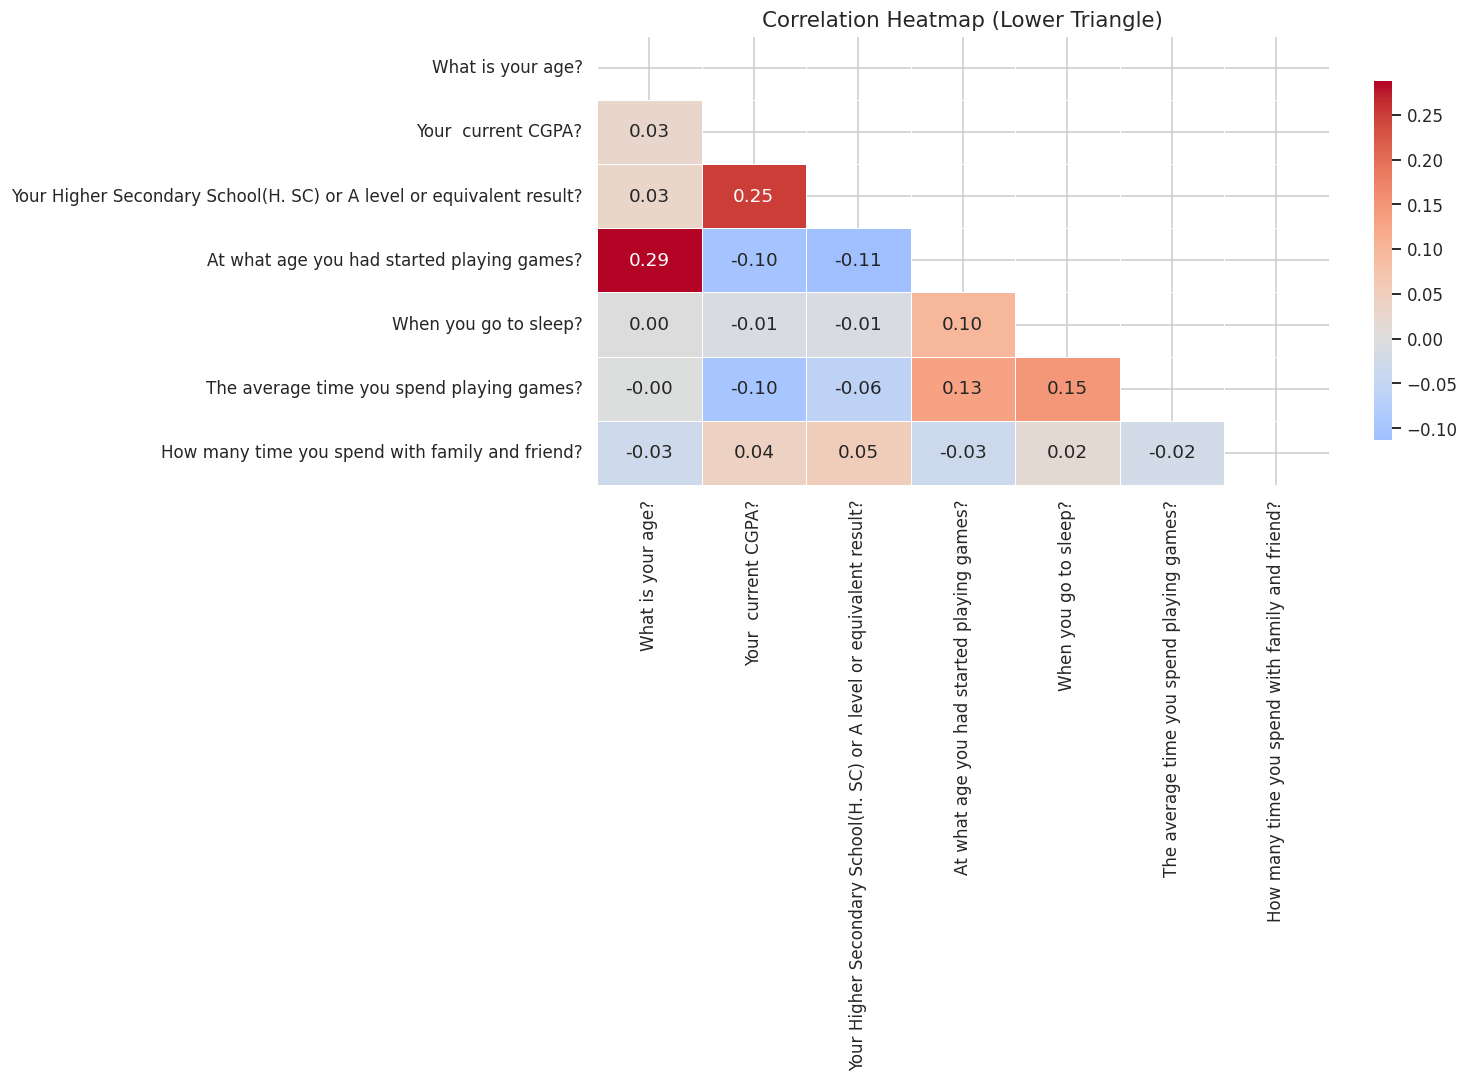


🎯 Top Correlations with 'Your  current CGPA?':
Your Higher Secondary School(H. SC) or A level or equivalent result?    0.251213
At what age you had started playing games?                             -0.103499
The average time you spend playing games?                              -0.099934
How many time you spend with family and friend?                         0.042843
What is your age?                                                       0.026170
When you go to sleep?                                                  -0.010528


In [ ]:
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap (Lower Triangle)", fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with target
print(f"\n🎯 Top Correlations with '{TARGET}':")
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print(target_corr.head(10).to_string())

## Pairplot for Top Correlated Features

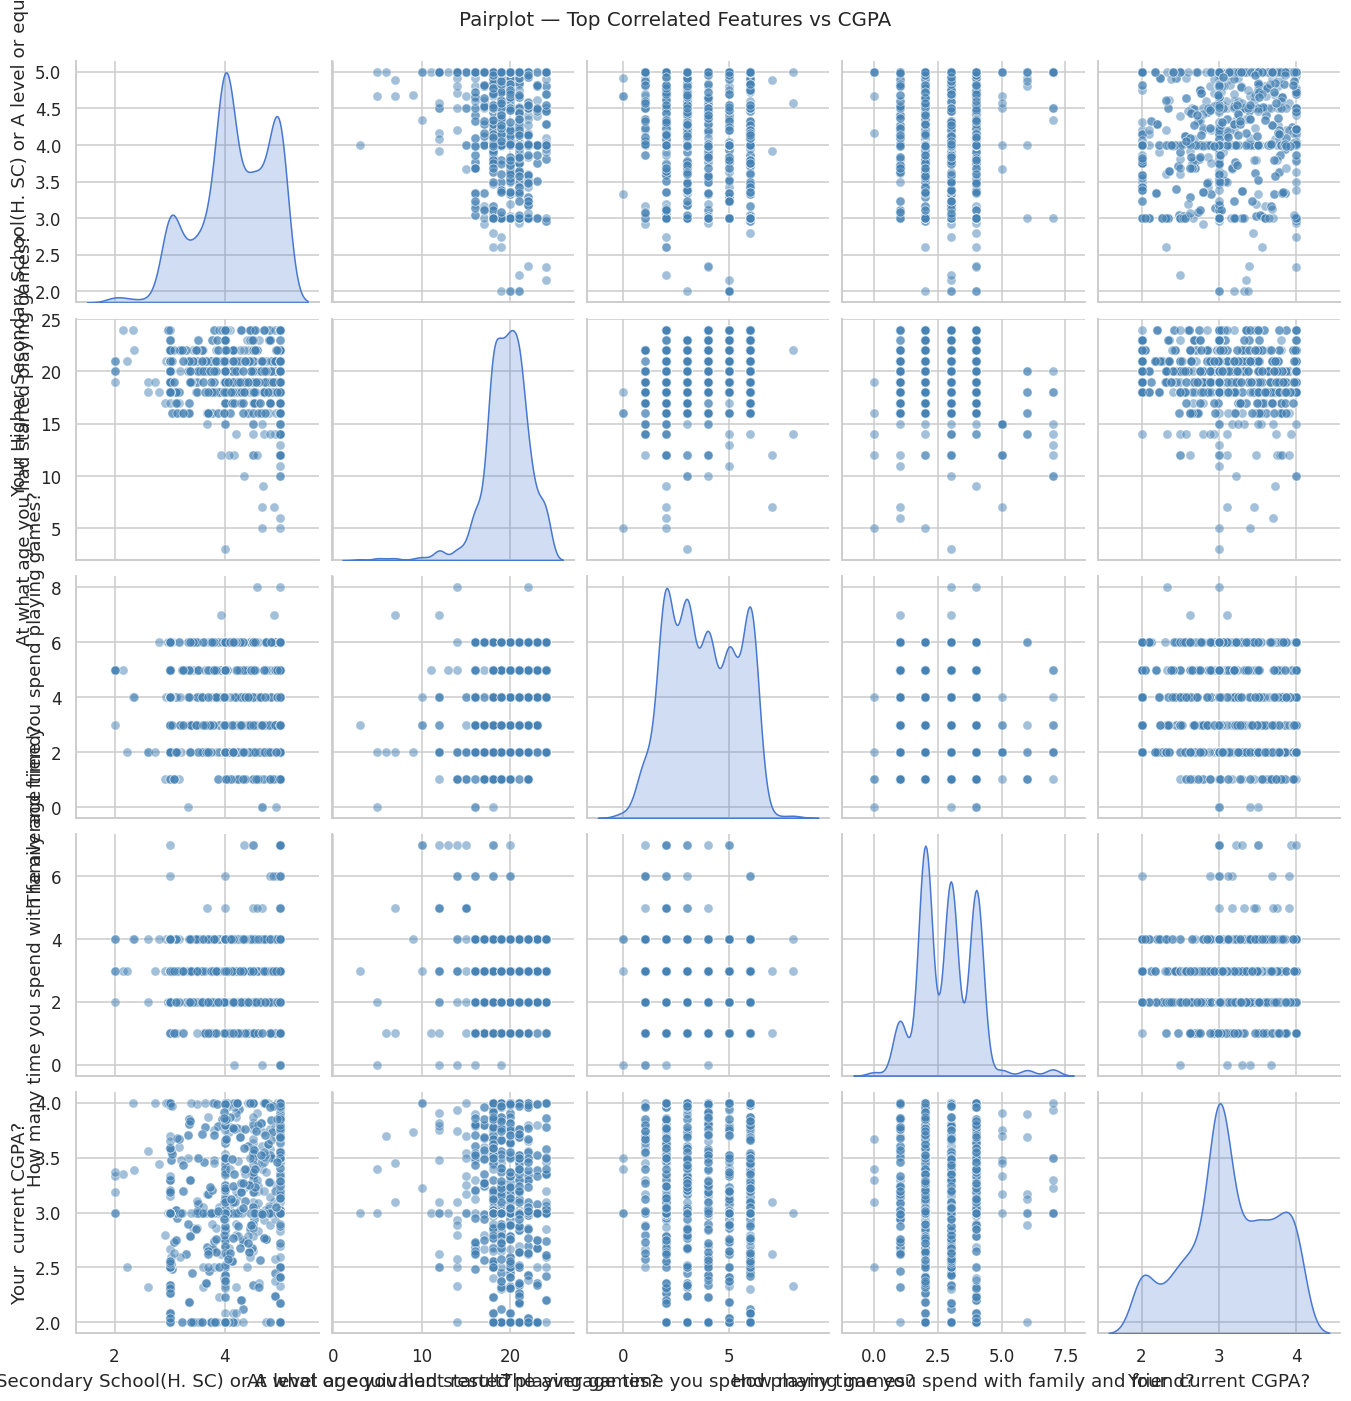

In [ ]:
top_features = target_corr.abs().head(4).index.tolist()
pairplot_cols = top_features + [TARGET]

sns.pairplot(
    df[pairplot_cols].dropna(),
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 'color': 'steelblue'}
)
plt.suptitle("Pairplot — Top Correlated Features vs CGPA", y=1.02, fontsize=13)
plt.show()

##  Feature Engineering

In [ ]:
df_fe = df.copy()

# ── Identify column types ─────────────────────────────────────────────
gaming_cols = [c for c in df_fe.columns
               if any(kw in c.lower() for kw in ['game', 'play', 'hour', 'gaming'])
               and c != TARGET]

gaming_num_cols = [c for c in gaming_cols if pd.api.types.is_numeric_dtype(df_fe[c])]
gaming_cat_cols = [c for c in gaming_cols if not pd.api.types.is_numeric_dtype(df_fe[c])]
num_cols_fe     = df_fe.select_dtypes(include=np.number).columns.tolist()
num_cols_fe     = [c for c in num_cols_fe if c != TARGET]

print(f"Gaming numeric columns   ({len(gaming_num_cols)}): {gaming_num_cols}")
print(f"Gaming categorical cols  ({len(gaming_cat_cols)}): {gaming_cat_cols[:3]} ...")
print(f"All numeric feature cols ({len(num_cols_fe)})")

# ── Feature 1: Average time spent gaming (encode ordinal if categorical)
time_col = next((c for c in gaming_cat_cols if 'time' in c.lower() or 'average' in c.lower()), None)
if time_col:
    time_map = {
        'Less than 1 hour': 0.5, '1-2 hours': 1.5, '2-3 hours': 2.5,
        '3-5 hours': 4.0,  'More than 5 hours': 6.0,
        '1 hour': 1.0, '2 hours': 2.0, '3 hours': 3.0,
        '4 hours': 4.0, '5 hours': 5.0
    }
    mapped = df_fe[time_col].map(time_map)
    if mapped.notna().sum() > 0:
        df_fe['gaming_hours_numeric'] = mapped.fillna(mapped.median())
        gaming_num_cols.append('gaming_hours_numeric')
        num_cols_fe.append('gaming_hours_numeric')
        print(f"✅ Created: gaming_hours_numeric  (ordinal encode of '{time_col[:40]}')")
    else:
        # Fallback: label-encode the time column as ordinal proxy
        df_fe['gaming_hours_numeric'] = LabelEncoder().fit_transform(df_fe[time_col].astype(str))
        gaming_num_cols.append('gaming_hours_numeric')
        num_cols_fe.append('gaming_hours_numeric')
        print(f"✅ Created: gaming_hours_numeric  (label-encoded fallback)")

# ── Feature 2: Number of unique game types played (diversity score) ───
type_cols = [c for c in gaming_cat_cols if 'type' in c.lower()]
if len(type_cols) >= 2:
    df_fe['game_type_diversity'] = df_fe[type_cols].apply(
        lambda row: row.nunique(), axis=1
    )
    num_cols_fe.append('game_type_diversity')
    print("✅ Created: game_type_diversity")

# ── Feature 3: Stress-related gaming flag (binary) ────────────────────
stress_col = next((c for c in gaming_cat_cols if 'stress' in c.lower()), None)
if stress_col:
    df_fe['games_for_stress'] = df_fe[stress_col].str.lower() \
        .str.contains('yes|always|often|sometimes', na=False).astype(int)
    num_cols_fe.append('games_for_stress')
    print(f"✅ Created: games_for_stress  (binary flag from '{stress_col[:40]}')")

# ── Feature 4: Polynomial on most correlated NUMERIC feature ──────────
# target_corr was computed from numeric cols only — safe to use directly
if len(target_corr) >= 1:
    top_col = target_corr.abs().idxmax()
    if pd.api.types.is_numeric_dtype(df_fe[top_col]):
        df_fe[f'{top_col[:20]}_squared'] = df_fe[top_col] ** 2
        num_cols_fe.append(f'{top_col[:20]}_squared')
        print(f"✅ Created polynomial: {top_col[:20]}_squared")

# ── Feature 5: Interaction between top-2 numeric correlated features ──
if len(target_corr) >= 2:
    top2 = target_corr.abs().nlargest(2).index.tolist()
    col_a, col_b = top2[0], top2[1]
    if (pd.api.types.is_numeric_dtype(df_fe[col_a]) and
            pd.api.types.is_numeric_dtype(df_fe[col_b])):
        feat_name = f'{col_a[:10]}_x_{col_b[:10]}'
        df_fe[feat_name] = df_fe[col_a] * df_fe[col_b]
        num_cols_fe.append(feat_name)
        print(f"✅ Created interaction: {feat_name}")

print(f"\nNew shape after feature engineering: {df_fe.shape}")

Gaming numeric columns   (2): ['At what age you had started playing games?', 'The average time you spend playing games?']
Gaming categorical cols  (7): ['Do you play games on mobile or pc?', 'Which type of game you addict more?', 'Which type of game you played most?'] ...
All numeric feature cols (6)
✅ Created: game_type_diversity
✅ Created: games_for_stress  (binary flag from 'Do you play games for stress relief?')
✅ Created polynomial: Your Higher Secondar_squared
✅ Created interaction: Your Highe_x_At what ag

New shape after feature engineering: (989, 24)


##  Preprocessing: Encode & Scale (No Leakage)

In [ ]:
# Separate features and target
X = df_fe.drop(columns=[TARGET])
y = df_fe[TARGET]

# Identify column types
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols   = X.select_dtypes(include=np.number).columns.tolist()

print(f"Numerical columns  ({len(numerical_cols)}): {numerical_cols[:5]} ...")
print(f"Categorical columns({len(categorical_cols)}): {categorical_cols}")

# ── Pipelines per column type ─────────────────────────────────────────
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── ColumnTransformer: combines both pipelines ────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline,   numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
], remainder='drop')

print("\n✅ Preprocessor built (OneHotEncoder for categoricals — no label leakage)")

Numerical columns  (10): ['What is your age?', 'Your Higher Secondary School(H. SC) or A level or equivalent result?', 'At what age you had started playing games?', 'When you go to sleep?', 'The average time you spend playing games?'] ...
Categorical columns(13): ['Current educational position?', 'Gender?', 'Do you play games on mobile or pc?', 'Do you attend your morning class regularly?', 'Which type of game you addict more?', 'Do you read newspaper?', 'Which type of game you played most?', 'How you fill when you can not play game in whole day?', 'How you fill to complete game level?', "If you didn't finish games last level what is your feeling?", 'Do you fill Fatigue?', 'Do you play games for stress relief?', 'Are you wearing glasses?']

✅ Preprocessor built (OneHotEncoder for categoricals — no label leakage)


##  Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train set : {X_train.shape[0]} samples")
print(f"Test set  : {X_test.shape[0]} samples")
print(f"Train CGPA mean: {y_train.mean():.4f}  |  Test CGPA mean: {y_test.mean():.4f}")

Train set : 791 samples
Test set  : 198 samples
Train CGPA mean: 3.1368  |  Test CGPA mean: 3.1044


##  Define All Regression Models (Pipelines)

In [ ]:
def make_pipeline(model):
    """Wrap preprocessor + model into a single sklearn Pipeline."""
    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

regression_models = {
    'Linear Regression'    : make_pipeline(LinearRegression()),
    'Ridge'                : make_pipeline(Ridge(alpha=1.0)),
    'Lasso'                : make_pipeline(Lasso(alpha=0.01, max_iter=5000)),
    'SVR'                  : make_pipeline(SVR(kernel='rbf', C=1.0)),
    'Random Forest'        : make_pipeline(RandomForestRegressor(n_estimators=200, random_state=42)),
    'Gradient Boosting'    : make_pipeline(GradientBoostingRegressor(n_estimators=200, random_state=42)),
    'MLP Neural Network'   : make_pipeline(MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)),
}

if XGB_OK:
    regression_models['XGBoost'] = make_pipeline(
        XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbosity=0)
    )
if LGB_OK:
    regression_models['LightGBM'] = make_pipeline(
        LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1)
    )

print(f"✅ {len(regression_models)} regression models ready:")
for name in regression_models:
    print(f"   • {name}")

✅ 9 regression models ready:
   • Linear Regression
   • Ridge
   • Lasso
   • SVR
   • Random Forest
   • Gradient Boosting
   • MLP Neural Network
   • XGBoost
   • LightGBM


##  10-Fold Cross-Validation on All Models

In [ ]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = {}
print(f"{'Model':<25} {'CV R² Mean':>12} {'CV R² Std':>12} {'CV RMSE Mean':>14}")
print("-" * 65)

for name, pipe in regression_models.items():
    r2_scores   = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2',
                                  n_jobs=-1)
    rmse_scores = np.sqrt(-cross_val_score(pipe, X_train, y_train, cv=cv,
                                           scoring='neg_mean_squared_error',
                                           n_jobs=-1))
    cv_results[name] = {
        'r2_mean'   : r2_scores.mean(),
        'r2_std'    : r2_scores.std(),
        'rmse_mean' : rmse_scores.mean(),
        'rmse_std'  : rmse_scores.std()
    }
    print(f"{name:<25} {r2_scores.mean():>12.4f} {r2_scores.std():>12.4f} {rmse_scores.mean():>14.4f}")

best_cv_model = max(cv_results, key=lambda k: cv_results[k]['r2_mean'])
print(f"\n🏆 Best CV model: {best_cv_model} (R² = {cv_results[best_cv_model]['r2_mean']:.4f})")

Model                       CV R² Mean    CV R² Std   CV RMSE Mean
-----------------------------------------------------------------
Linear Regression               0.0217       0.1024         0.5478
Ridge                           0.0227       0.0956         0.5476
Lasso                           0.0286       0.0729         0.5465
SVR                             0.3668       0.1301         0.4373
Random Forest                   0.4301       0.1040         0.4166
Gradient Boosting               0.3149       0.0906         0.4574
MLP Neural Network              0.3169       0.1591         0.4530
XGBoost                         0.4370       0.1078         0.4130
LightGBM                        0.4193       0.1059         0.4197

🏆 Best CV model: XGBoost (R² = 0.4370)


##  CV Results Bar Chart

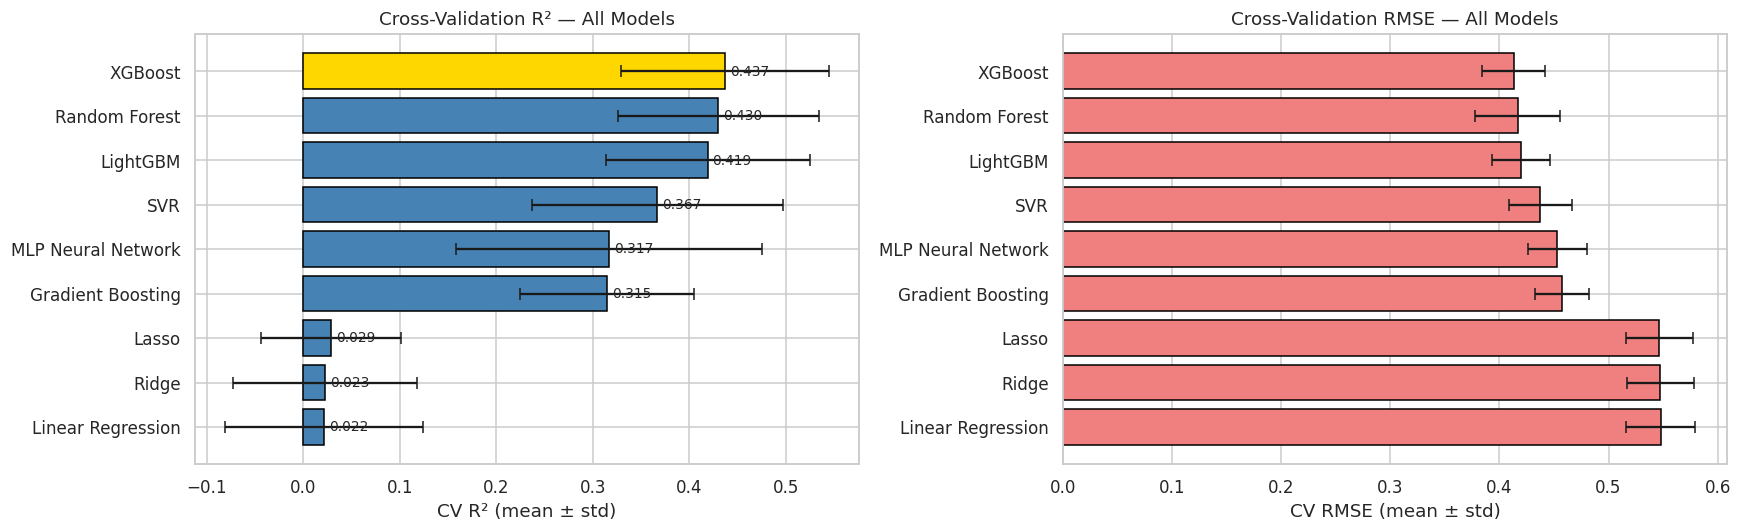

In [ ]:
cv_df = pd.DataFrame(cv_results).T.sort_values('r2_mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# R² comparison
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(cv_df))]
bars = axes[0].barh(cv_df.index, cv_df['r2_mean'], xerr=cv_df['r2_std'],
                    color=colors, edgecolor='black', capsize=4)
axes[0].set_xlabel("CV R² (mean ± std)")
axes[0].set_title("Cross-Validation R² — All Models")
axes[0].invert_yaxis()
for bar, val in zip(bars, cv_df['r2_mean']):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# RMSE comparison
axes[1].barh(cv_df.index, cv_df['rmse_mean'], xerr=cv_df['rmse_std'],
             color='lightcoral', edgecolor='black', capsize=4)
axes[1].set_xlabel("CV RMSE (mean ± std)")
axes[1].set_title("Cross-Validation RMSE — All Models")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

##  Hyperparameter Tuning (Best Model)

In [ ]:
print(f"Tuning: {best_cv_model}")

# ── Parameter grids per model ─────────────────────────────────────────
tuning_grids = {
    'Random Forest': {
        'model__n_estimators' : [100, 200, 400],
        'model__max_depth'    : [None, 5, 10, 20],
        'model__min_samples_split': [2, 5, 10],
        'model__max_features' : ['sqrt', 'log2']
    },
    'Gradient Boosting': {
        'model__n_estimators' : [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth'    : [3, 5, 7],
        'model__subsample'    : [0.7, 1.0]
    },
    'XGBoost': {
        'model__n_estimators' : [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth'    : [3, 5, 7],
        'model__subsample'    : [0.7, 1.0]
    },
    'LightGBM': {
        'model__n_estimators' : [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__num_leaves'   : [31, 63, 127]
    },
    'Ridge': {
        'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'Lasso': {
        'model__alpha': [0.001, 0.01, 0.1, 1.0]
    },
    'SVR': {
        'model__C'      : [0.1, 1.0, 10.0],
        'model__epsilon': [0.01, 0.1, 0.5],
        'model__kernel' : ['rbf', 'linear']
    },
    'MLP Neural Network': {
        'model__hidden_layer_sizes': [(64,), (128, 64), (256, 128, 64)],
        'model__alpha'             : [0.0001, 0.001, 0.01],
        'model__learning_rate_init': [0.001, 0.01]
    },
    'Linear Regression': {}   # no hyperparameters to tune
}

param_grid = tuning_grids.get(best_cv_model, {})

best_pipe = regression_models[best_cv_model]

if param_grid:
    search = RandomizedSearchCV(
        best_pipe, param_grid,
        n_iter=30, cv=5, scoring='r2',
        n_jobs=-1, random_state=42, verbose=1
    )
    search.fit(X_train, y_train)
    tuned_model = search.best_estimator_
    print(f"\n✅ Best params: {search.best_params_}")
    print(f"✅ Best CV R²: {search.best_score_:.4f}")
else:
    tuned_model = best_pipe
    tuned_model.fit(X_train, y_train)
    print("No hyperparameters to tune for Linear Regression — fitted directly.")

Tuning: XGBoost
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best params: {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.05}
✅ Best CV R²: 0.4311


## Full Test Set Evaluation (All Models)

In [ ]:
results = []

for name, pipe in regression_models.items():
    if name == best_cv_model:
        pipe = tuned_model   # use tuned version
    else:
        pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    results.append({
        'Model' : name,
        'MAE'   : mean_absolute_error(y_test, y_pred),
        'MSE'   : mean_squared_error(y_test, y_pred),
        'RMSE'  : np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAPE'  : mean_absolute_percentage_error(y_test, y_pred) * 100,
        'R²'    : r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
results_df.index += 1   # rank starts from 1

print("📋 Model Comparison Table (Test Set)")
print(results_df.to_string(float_format=lambda x: f"{x:.4f}"))

📋 Model Comparison Table (Test Set)
                Model    MAE    MSE   RMSE    MAPE     R²
1             XGBoost 0.2367 0.1490 0.3860  7.9111 0.5179
2       Random Forest 0.2894 0.1596 0.3994  9.7471 0.4838
3            LightGBM 0.2787 0.1604 0.4005  9.3804 0.4812
4  MLP Neural Network 0.2554 0.1842 0.4292  8.4194 0.4040
5                 SVR 0.3183 0.1955 0.4422 10.9877 0.3674
6   Gradient Boosting 0.3451 0.2047 0.4524 11.9542 0.3378
7               Lasso 0.4215 0.2750 0.5244 14.8657 0.1103
8               Ridge 0.4140 0.2776 0.5269 14.6194 0.1020
9   Linear Regression 0.4123 0.2778 0.5270 14.5778 0.1014


## Residual Analysis on Best Model

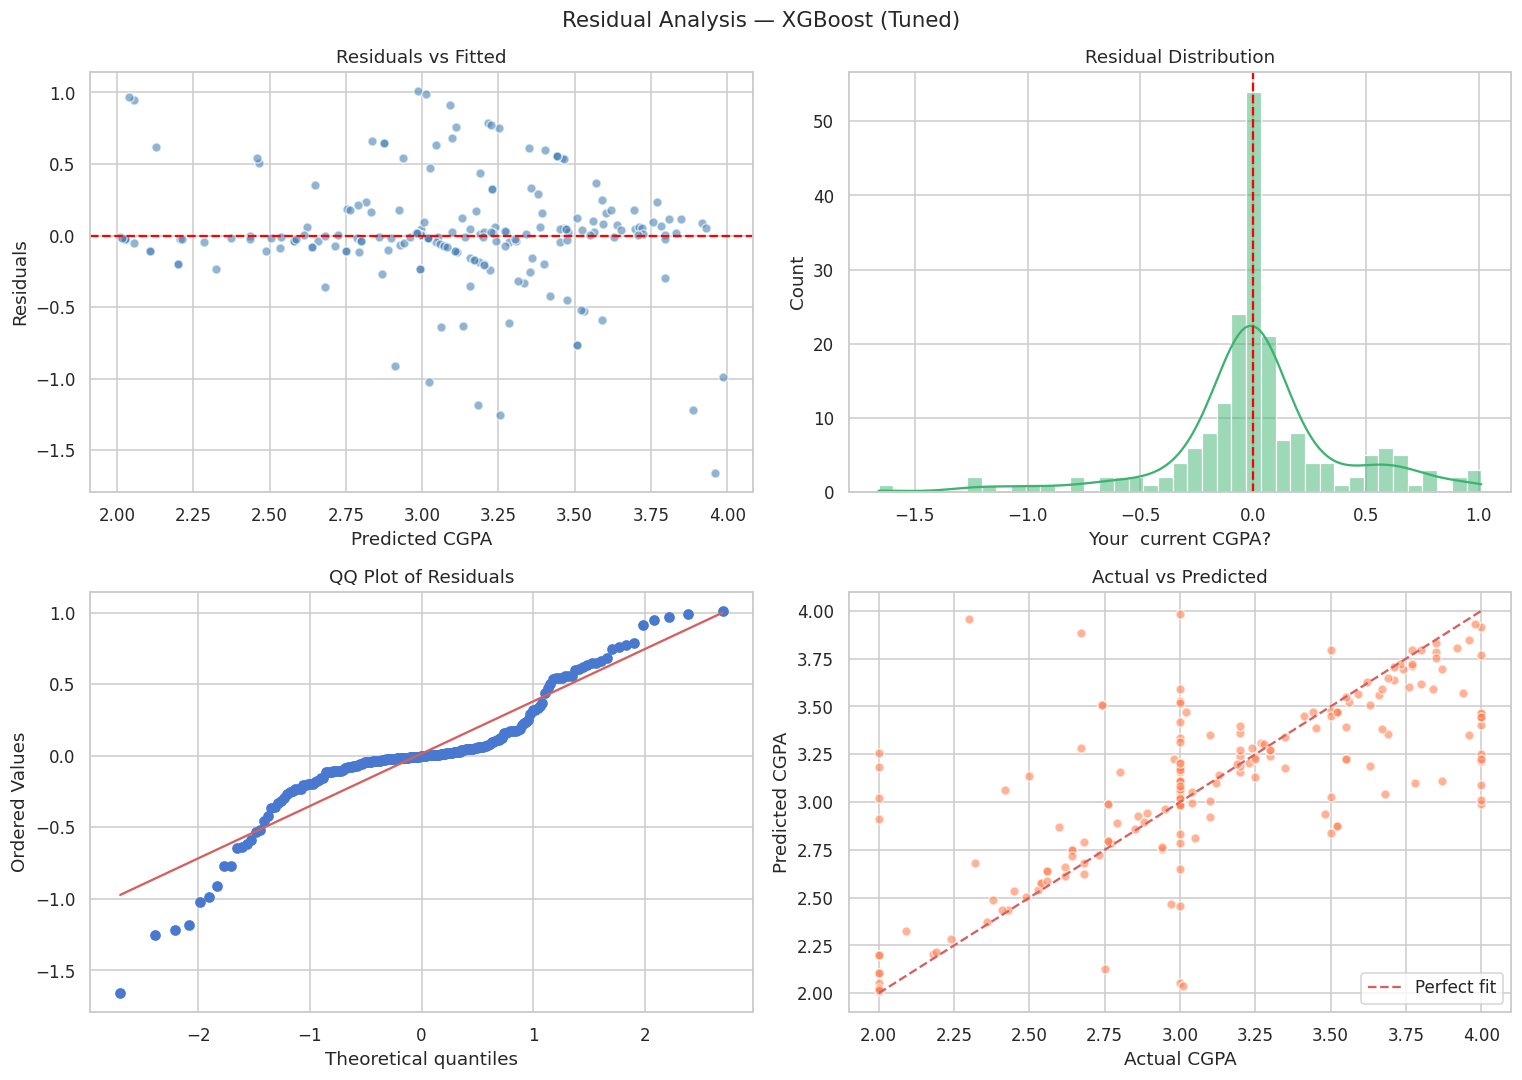

Shapiro-Wilk on residuals: p=0.0000 → Non-normal residuals ⚠️
Mean residual : 0.014050 (should be ~0)


In [ ]:
y_pred_best = tuned_model.predict(X_test)
residuals   = y_test - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 — Residuals vs Fitted
axes[0, 0].scatter(y_pred_best, residuals, alpha=0.6, color='steelblue', edgecolors='white')
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_xlabel("Predicted CGPA")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")

# 2 — Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[0, 1], color='mediumseagreen')
axes[0, 1].axvline(0, color='red', linestyle='--')
axes[0, 1].set_title("Residual Distribution")

# 3 — QQ Plot of Residuals
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ Plot of Residuals")

# 4 — Actual vs Predicted
axes[1, 1].scatter(y_test, y_pred_best, alpha=0.6, color='coral', edgecolors='white')
mn, mx = min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())
axes[1, 1].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
axes[1, 1].set_xlabel("Actual CGPA")
axes[1, 1].set_ylabel("Predicted CGPA")
axes[1, 1].set_title("Actual vs Predicted")
axes[1, 1].legend()

plt.suptitle(f"Residual Analysis — {best_cv_model} (Tuned)", fontsize=14)
plt.tight_layout()
plt.show()

# Statistical test on residuals
stat, p = stats.shapiro(residuals)
print(f"Shapiro-Wilk on residuals: p={p:.4f} → {'Residuals approx normal ✅' if p > 0.05 else 'Non-normal residuals ⚠️'}")
print(f"Mean residual : {residuals.mean():.6f} (should be ~0)")

##  SHAP Explainability (Best Model)

📌 SHAP Summary Plot — Feature Importance & Direction


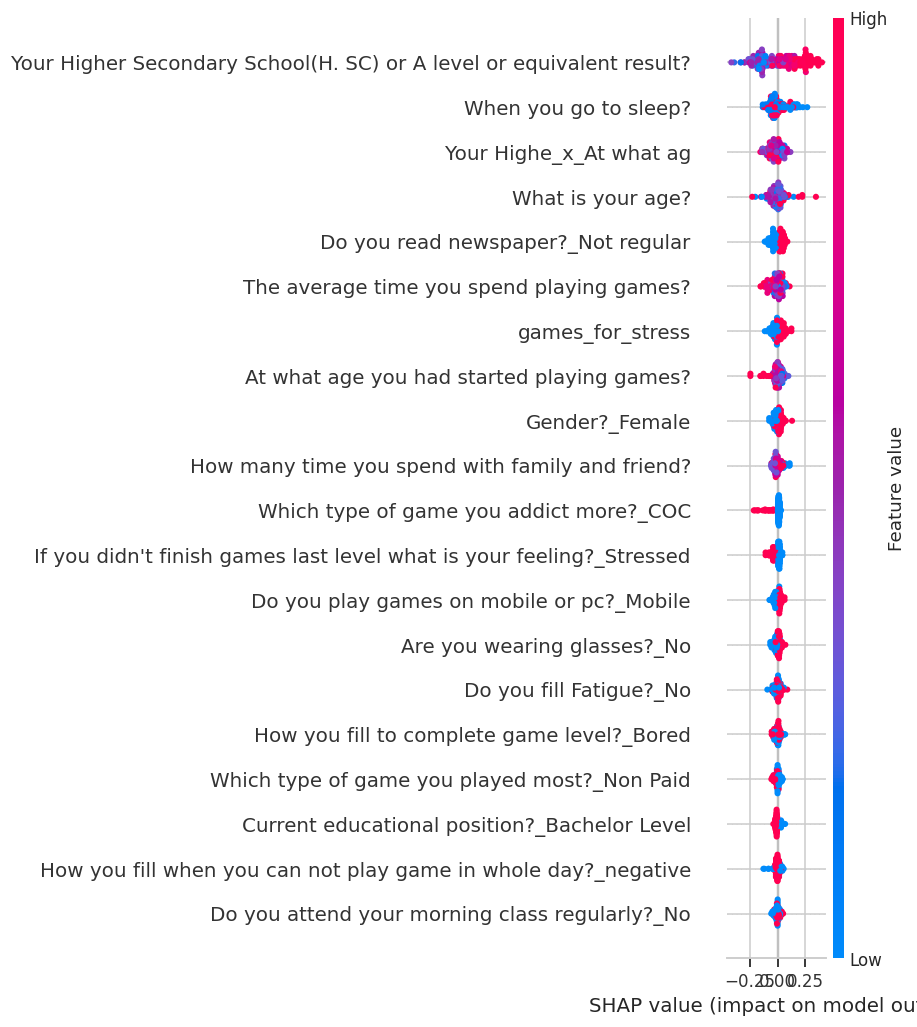


📌 SHAP Bar Plot — Mean |SHAP| per Feature


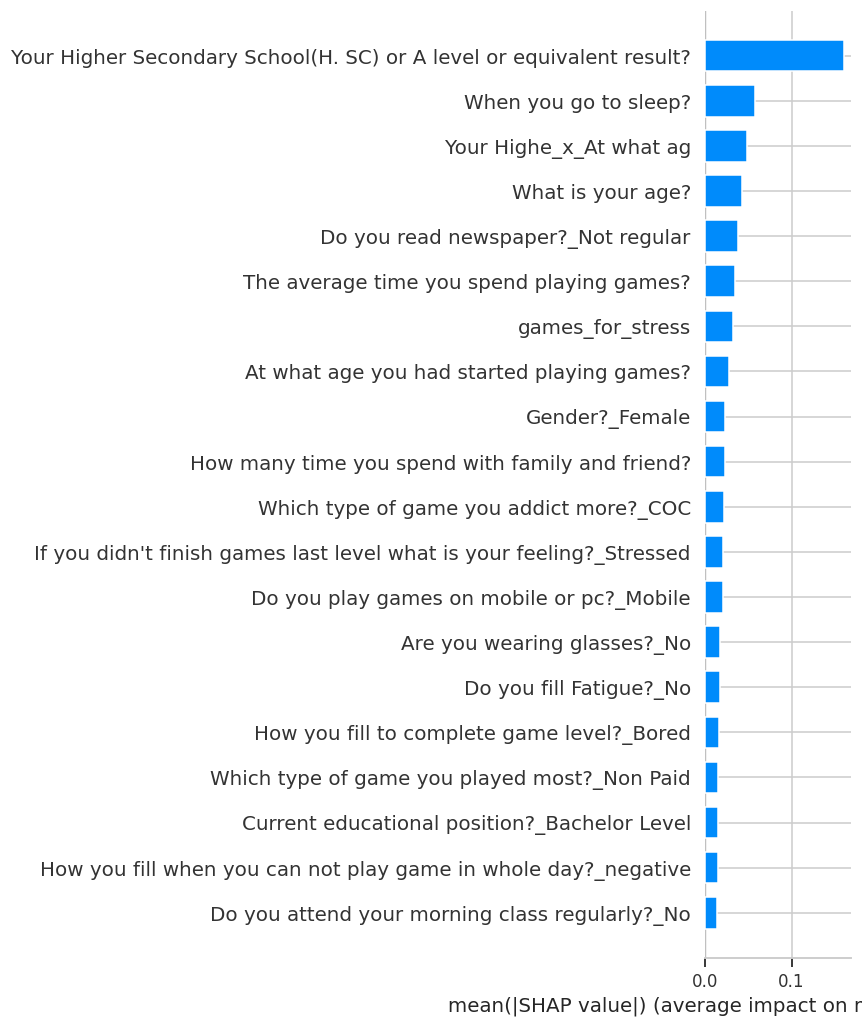

In [ ]:
if SHAP_OK:
    # Transform test data through the preprocessor step
    X_test_transformed = tuned_model.named_steps['preprocessor'].transform(X_test)

    # Get feature names after OneHotEncoding
    try:
        num_names = numerical_cols
        cat_names = tuned_model.named_steps['preprocessor'] \
                      .named_transformers_['cat'] \
                      .named_steps['encoder'] \
                      .get_feature_names_out(categorical_cols).tolist()
        feature_names = num_names + cat_names
    except Exception:
        feature_names = [f"f{i}" for i in range(X_test_transformed.shape[1])]

    final_model = tuned_model.named_steps['model']

    # Use TreeExplainer for tree-based, KernelExplainer otherwise
    tree_models = (RandomForestRegressor, GradientBoostingRegressor)
    if XGB_OK: tree_models += (XGBRegressor,)
    if LGB_OK: tree_models += (LGBMRegressor,)

    if isinstance(final_model, tree_models):
        explainer  = shap.TreeExplainer(final_model)
        shap_vals  = explainer.shap_values(X_test_transformed)
    else:
        bg = shap.sample(X_test_transformed, min(50, len(X_test_transformed)))
        explainer = shap.KernelExplainer(final_model.predict, bg)
        shap_vals = explainer.shap_values(X_test_transformed[:50], nsamples=100)

    print("📌 SHAP Summary Plot — Feature Importance & Direction")
    shap.summary_plot(
        shap_vals, X_test_transformed,
        feature_names=feature_names, show=True
    )

    print("\n📌 SHAP Bar Plot — Mean |SHAP| per Feature")
    shap.summary_plot(
        shap_vals, X_test_transformed,
        feature_names=feature_names,
        plot_type='bar', show=True
    )
else:
    print("⚠️ SHAP not installed. Run: pip install shap")

##  Feature Importance (Random Forest Fallback)

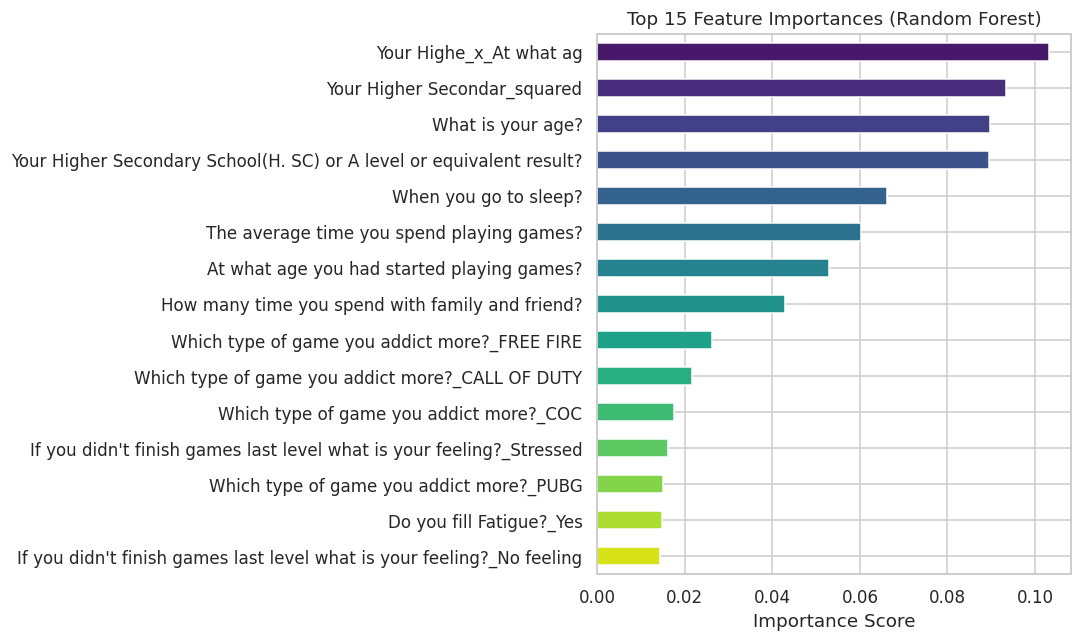

In [ ]:
# Fit a fresh RF for feature importance (works even if best model is not RF)
rf_pipe = regression_models.get('Random Forest', make_pipeline(RandomForestRegressor(n_estimators=200, random_state=42)))
rf_pipe.fit(X_train, y_train)

rf_model   = rf_pipe.named_steps['model']
importances = rf_model.feature_importances_

# Match feature names after preprocessing
try:
    ohe_names = rf_pipe.named_steps['preprocessor'] \
                       .named_transformers_['cat'] \
                       .named_steps['encoder'] \
                       .get_feature_names_out(categorical_cols).tolist()
    all_feature_names = numerical_cols + ohe_names
except Exception:
    all_feature_names = [f"feature_{i}" for i in range(len(importances))]

feat_imp = pd.Series(importances, index=all_feature_names) \
             .sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = sns.color_palette('viridis', len(feat_imp))
feat_imp.plot(kind='barh', color=colors)
plt.xlabel("Importance Score")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Classification Task: CGPA Category Prediction

In [ ]:
# ── Create CGPA categories ────────────────────────────────────────────
df_cls = df_fe.copy()
df_cls['CGPA_Category'] = pd.cut(
    df_cls[TARGET],
    bins=[0, 2.5, 3.0, 3.5, 4.0],
    labels=['Low', 'Medium', 'High', 'Excellent']
)
df_cls.dropna(subset=['CGPA_Category'], inplace=True)

print("CGPA Category Distribution:")
print(df_cls['CGPA_Category'].value_counts().sort_index())

# Encode labels
le_cls = LabelEncoder()
df_cls['CGPA_Cat_Encoded'] = le_cls.fit_transform(df_cls['CGPA_Category'])

X_cls = df_cls.drop(columns=[TARGET, 'CGPA_Category', 'CGPA_Cat_Encoded'])
y_cls = df_cls['CGPA_Cat_Encoded']

# ── Stratified split ──────────────────────────────────────────────────
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=42, stratify=y_cls   # stratified!
)
print(f"\nClassification train: {X_train_c.shape[0]} | test: {X_test_c.shape[0]}")

CGPA Category Distribution:
CGPA_Category
Low          151
Medium       332
High         229
Excellent    277
Name: count, dtype: int64

Classification train: 791 | test: 198


## Classification Models + Cross-Validation

In [ ]:
clf_models = {
    'Logistic Regression': make_pipeline(LogisticRegression(max_iter=1000, random_state=42)),
    'Random Forest'      : make_pipeline(RandomForestClassifier(n_estimators=200, random_state=42)),
    'Gradient Boosting'  : make_pipeline(GradientBoostingClassifier(n_estimators=200, random_state=42)),
    'SVM (RBF)'          : make_pipeline(SVC(kernel='rbf', probability=True, random_state=42)),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_results = []
print(f"{'Model':<22} {'CV Accuracy':>12} {'CV Std':>10}")
print("-" * 46)

for name, pipe in clf_models.items():
    scores = cross_val_score(pipe, X_train_c, y_train_c, cv=skf, scoring='accuracy', n_jobs=-1)
    clf_results.append({'Model': name, 'CV Acc Mean': scores.mean(), 'CV Acc Std': scores.std()})
    print(f"{name:<22} {scores.mean():>12.4f} {scores.std():>10.4f}")

best_clf_name = max(clf_results, key=lambda x: x['CV Acc Mean'])['Model']
print(f"\n🏆 Best classifier: {best_clf_name}")

Model                   CV Accuracy     CV Std
----------------------------------------------
Logistic Regression          0.4122     0.0388
Random Forest                0.6611     0.0267
Gradient Boosting            0.6296     0.0191
SVM (RBF)                    0.5310     0.0356

🏆 Best classifier: Random Forest


##  Confusion Matrix & Classification Report

Test Accuracy : 0.6970

Classification Report:
              precision    recall  f1-score   support

   Excellent       0.71      0.76      0.74        55
        High       0.62      0.65      0.64        46
         Low       0.76      0.53      0.63        30
      Medium       0.71      0.75      0.73        67

    accuracy                           0.70       198
   macro avg       0.70      0.67      0.68       198
weighted avg       0.70      0.70      0.70       198



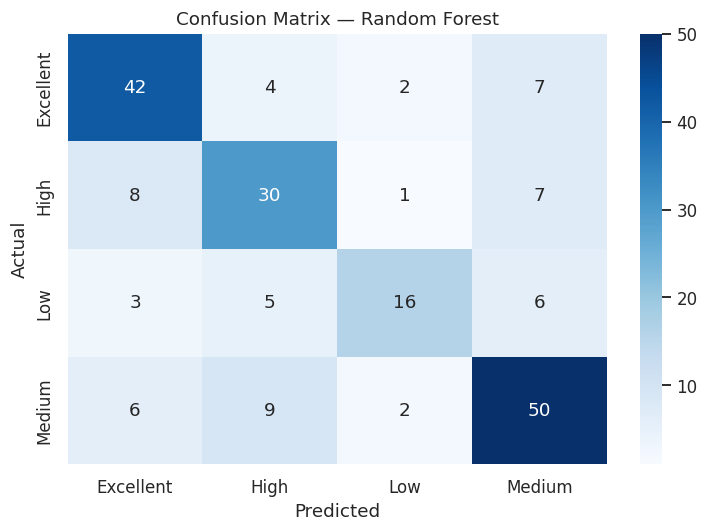

In [ ]:
best_clf = clf_models[best_clf_name]
best_clf.fit(X_train_c, y_train_c)
y_pred_cls = best_clf.predict(X_test_c)

print(f"Test Accuracy : {accuracy_score(y_test_c, y_pred_cls):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_cls, target_names=le_cls.classes_))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test_c, y_pred_cls)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le_cls.classes_,
    yticklabels=le_cls.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_clf_name}")
plt.tight_layout()
plt.show()

##  ROC Curves (One-vs-Rest for Multi-Class)

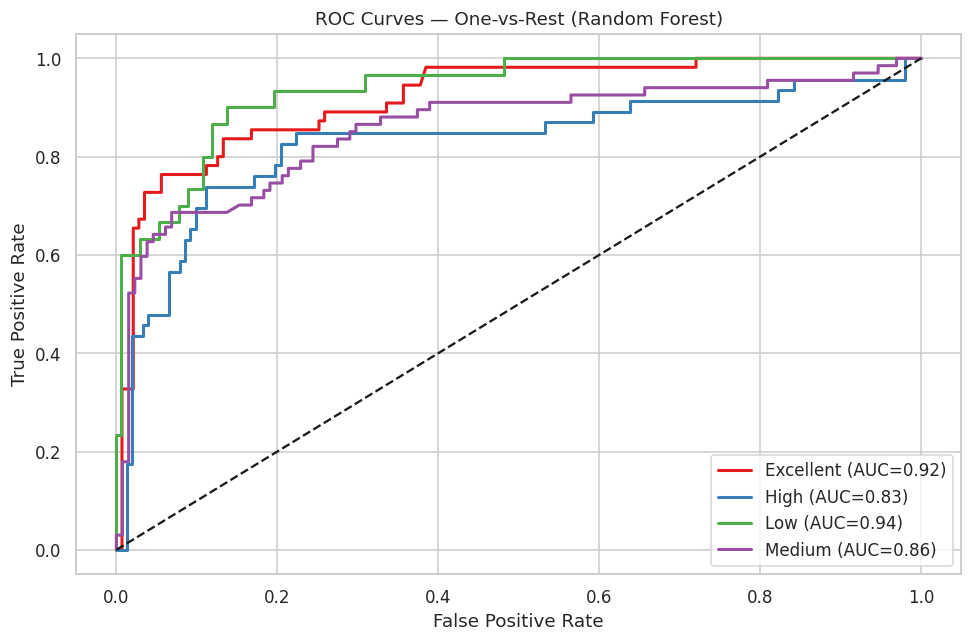

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

classes = np.unique(y_cls)
y_test_bin = label_binarize(y_test_c, classes=classes)

# Use a classifier that supports predict_proba for OvR
ovr_clf = OneVsRestClassifier(
    Pipeline([('preprocessor', preprocessor),
              ('model', RandomForestClassifier(n_estimators=200, random_state=42))])
)
ovr_clf.fit(X_train_c, y_train_c)
y_score = ovr_clf.predict_proba(X_test_c)

plt.figure(figsize=(9, 6))
colors_roc = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

for i, (cls_label, color) in enumerate(zip(le_cls.classes_, colors_roc)):
    if i < y_test_bin.shape[1] and i < y_score.shape[1]:
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc_score   = roc_auc_score(y_test_bin[:, i], y_score[:, i])
        plt.plot(fpr, tpr, color=color, lw=2, label=f"{cls_label} (AUC={auc_score:.2f})")

plt.plot([0,1],[0,1], 'k--', lw=1.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — One-vs-Rest (Random Forest)")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

##  Hypothesis Testing: Pearson Correlation

In [ ]:
print("=" * 65)
print("HYPOTHESIS 1: Does Gaming Behavior Correlate with CGPA?")
print("H\u2080: \u03c1 = 0  (no linear relationship)")
print("H\u2081: \u03c1 \u2260 0  (significant linear relationship)")
print("=" * 65)

# Use df_fe which has engineered numeric proxies for gaming features
all_gaming_candidates = [c for c in df_fe.columns
                          if any(kw in c.lower() for kw in ['game','play','hour','gaming','stress'])
                          and c != TARGET]
gaming_num_hyp = [c for c in all_gaming_candidates
                  if pd.api.types.is_numeric_dtype(df_fe[c])]
gaming_cat_hyp = [c for c in all_gaming_candidates
                  if not pd.api.types.is_numeric_dtype(df_fe[c])]

print(f"\nPearson correlation (numeric gaming features - {len(gaming_num_hyp)} cols):")
if gaming_num_hyp:
    for col in gaming_num_hyp:
        clean = df_fe[[col, TARGET]].dropna()
        corr, p = stats.pearsonr(clean[col], clean[TARGET])
        verdict = "Reject H0 - significant" if p < 0.05 else "Fail to reject H0"
        print(f"  {col[:45]:<47}  r={corr:+.4f}  p={p:.4f}  -> {verdict}")
else:
    print("  No numeric gaming cols - using Spearman on ordinal proxy.")
    if 'gaming_hours_numeric' in df_fe.columns:
        clean = df_fe[['gaming_hours_numeric', TARGET]].dropna()
        corr, p = stats.spearmanr(clean['gaming_hours_numeric'], clean[TARGET])
        print(f"  gaming_hours_numeric  r={corr:+.4f}  p={p:.4f}  -> {'Reject H0' if p < 0.05 else 'Fail to reject H0'}")

print(f"\nANOVA (categorical gaming features - {len(gaming_cat_hyp)} cols):")
for col in gaming_cat_hyp[:5]:
    groups_cat = [df_fe[df_fe[col] == val][TARGET].dropna()
                  for val in df_fe[col].dropna().unique()]
    groups_cat = [g for g in groups_cat if len(g) >= 3]
    if len(groups_cat) >= 2:
        f_stat, p = stats.f_oneway(*groups_cat)
        verdict = "Reject H0" if p < 0.05 else "Fail to reject H0"
        print(f"  {col[:50]:<52}  F={f_stat:.3f}  p={p:.4f}  -> {verdict} (ANOVA)")

HYPOTHESIS 1: Does Gaming Behavior Correlate with CGPA?
H₀: ρ = 0  (no linear relationship)
H₁: ρ ≠ 0  (significant linear relationship)

Pearson correlation (numeric gaming features - 4 cols):
  At what age you had started playing games?       r=-0.1035  p=0.0011  -> Reject H0 - significant
  The average time you spend playing games?        r=-0.0999  p=0.0017  -> Reject H0 - significant
  game_type_diversity                              r=+nan  p=nan  -> Fail to reject H0
  games_for_stress                                 r=+0.0649  p=0.0414  -> Reject H0 - significant

ANOVA (categorical gaming features - 7 cols):
  Do you play games on mobile or pc?                    F=2.821  p=0.0600  -> Fail to reject H0 (ANOVA)
  Which type of game you addict more?                   F=1.324  p=0.2434  -> Fail to reject H0 (ANOVA)
  Which type of game you played most?                   F=0.514  p=0.4735  -> Fail to reject H0 (ANOVA)
  How you fill when you can not play game in whole d    F=3.049

##  T-Test: Gamers vs Non-Gamers

In [ ]:
print("=" * 65)
print("HYPOTHESIS 2: High vs Low Gaming Group CGPA Difference")
print("H0: mean CGPA is equal across gamer groups")
print("H1: significant difference in mean CGPA")
print("=" * 65)

# Use numeric proxies only for T-test (needs numeric split point)
numeric_gaming_for_ttest = [c for c in df_fe.columns
    if any(kw in c.lower() for kw in ['gaming_hours_numeric','games_for_stress'])
    and pd.api.types.is_numeric_dtype(df_fe[c])]

# Also include any originally numeric gaming cols
numeric_gaming_for_ttest += [c for c in df_fe.columns
    if any(kw in c.lower() for kw in ['game','play','hour','gaming'])
    and c != TARGET
    and pd.api.types.is_numeric_dtype(df_fe[c])
    and c not in numeric_gaming_for_ttest]

if not numeric_gaming_for_ttest:
    print("No numeric gaming features available for T-test.")
    print("Using categorical grouping instead (group by each unique category):")
    gaming_cat_col = next((c for c in df_fe.columns
                           if any(kw in c.lower() for kw in ['game','play','hour','gaming'])
                           and c != TARGET), None)
    if gaming_cat_col:
        for val in df_fe[gaming_cat_col].dropna().unique()[:4]:
            grp_in  = df_fe[df_fe[gaming_cat_col] == val][TARGET].dropna()
            grp_out = df_fe[df_fe[gaming_cat_col] != val][TARGET].dropna()
            if len(grp_in) >= 3 and len(grp_out) >= 3:
                t_stat, p_val = stats.ttest_ind(grp_in, grp_out, equal_var=False)
                print(f"  '{val}' vs rest: t={t_stat:.3f}  p={p_val:.4f}  -> {'Reject H0' if p_val<0.05 else 'Fail to reject H0'}")
else:
    for gaming_feature in numeric_gaming_for_ttest[:3]:
        clean = df_fe[[gaming_feature, TARGET]].dropna()
        median_val = clean[gaming_feature].median()
        group_high = clean[clean[gaming_feature] > median_val][TARGET]
        group_low  = clean[clean[gaming_feature] <= median_val][TARGET]
        if len(group_high) < 2 or len(group_low) < 2:
            continue
        t_stat, p_val = stats.ttest_ind(group_high, group_low, equal_var=False)
        cohens_d = (group_high.mean() - group_low.mean()) / \
                   np.sqrt((group_high.std()**2 + group_low.std()**2) / 2)
        effect = 'large' if abs(cohens_d)>0.8 else 'medium' if abs(cohens_d)>0.5 else 'small'
        print(f"\nFeature : {gaming_feature}")
        print(f"  High group mean CGPA : {group_high.mean():.4f} (n={len(group_high)})")
        print(f"  Low group mean CGPA  : {group_low.mean():.4f} (n={len(group_low)})")
        print(f"  T-statistic : {t_stat:.4f}  |  P-value: {p_val:.4f}")
        print(f"  Cohen's d   : {cohens_d:.4f} ({effect} effect)")
        print(f"  -> {'Reject H0' if p_val < 0.05 else 'Fail to reject H0'}")

HYPOTHESIS 2: High vs Low Gaming Group CGPA Difference
H0: mean CGPA is equal across gamer groups
H1: significant difference in mean CGPA

Feature : At what age you had started playing games?
  High group mean CGPA : 3.0676 (n=355)
  Low group mean CGPA  : 3.1655 (n=634)
  T-statistic : -2.5928  |  P-value: 0.0097
  Cohen's d   : -0.1735 (small effect)
  -> Reject H0

Feature : The average time you spend playing games?
  High group mean CGPA : 3.0638 (n=356)
  Low group mean CGPA  : 3.1678 (n=633)
  T-statistic : -2.8252  |  P-value: 0.0049
  Cohen's d   : -0.1866 (small effect)
  -> Reject H0


##  ANOVA: Multiple Gaming Intensity Groups

HYPOTHESIS 3: CGPA Across Gaming Intensity Groups
H0: All group means equal
H1: At least one group differs

F-statistic : 2.8208
P-value     : 0.0600
-> No significant group difference


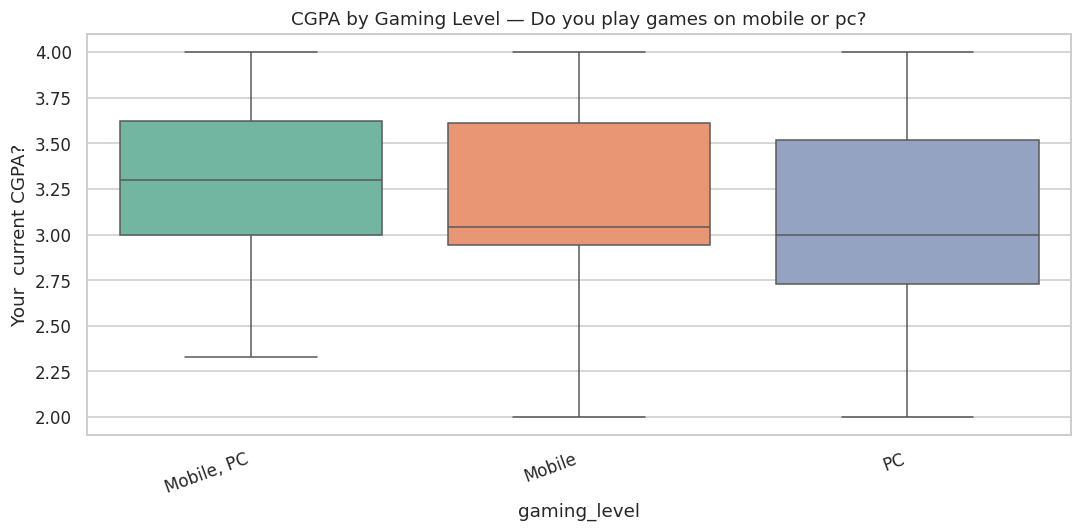

In [ ]:
print("=" * 65)
print("HYPOTHESIS 3: CGPA Across Gaming Intensity Groups")
print("H0: All group means equal")
print("H1: At least one group differs")
print("=" * 65)

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Prefer numeric proxy; fall back to categorical column directly
anova_feature_num = 'gaming_hours_numeric' if 'gaming_hours_numeric' in df_fe.columns else None
anova_feature_cat = next((c for c in df_fe.columns
    if any(kw in c.lower() for kw in ['game','play','hour','gaming'])
    and c != TARGET
    and not pd.api.types.is_numeric_dtype(df_fe[c])), None)

if anova_feature_num:
    # Numeric path: create Low/Medium/High bins with qcut
    clean = df_fe[[anova_feature_num, TARGET]].dropna()
    clean = clean.copy()
    clean['gaming_level'] = pd.qcut(clean[anova_feature_num], q=3,
                                    labels=['Low','Medium','High'], duplicates='drop')
    groups = [clean[clean['gaming_level'] == lvl][TARGET].values
              for lvl in ['Low','Medium','High'] if lvl in clean['gaming_level'].values]
    label_col, label_df = 'gaming_level', clean
    title_str = anova_feature_num

elif anova_feature_cat:
    # Categorical path: use each category as a group directly
    clean = df_fe[[anova_feature_cat, TARGET]].dropna().copy()
    clean['gaming_level'] = clean[anova_feature_cat]
    groups = [clean[clean['gaming_level'] == val][TARGET].values
              for val in clean['gaming_level'].unique()]
    groups = [g for g in groups if len(g) >= 3]
    label_col, label_df = 'gaming_level', clean
    title_str = anova_feature_cat[:40]
else:
    groups = []
    print("No suitable gaming feature found for ANOVA.")

if groups and len(groups) >= 2:
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"\nF-statistic : {f_stat:.4f}")
    print(f"P-value     : {p_val:.4f}")
    verdict = 'Reject H0 - significant group difference' if p_val < 0.05 else 'No significant group difference'
    print(f"-> {verdict}")

    plt.figure(figsize=(10, 5))
    unique_levels = label_df[label_col].unique().tolist()
    palette = sns.color_palette('Set2', len(unique_levels))
    sns.boxplot(data=label_df, x=label_col, y=TARGET, palette=palette)
    plt.title(f"CGPA by Gaming Level — {title_str}")
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

    if p_val < 0.05:
        print("\nTukey HSD Post-Hoc Test:")
        tukey = pairwise_tukeyhsd(label_df[TARGET], label_df[label_col].astype(str), alpha=0.05)
        print(tukey)

## 🧪 Cell 29 — OLS Regression Summary (statsmodels)

In [ ]:
# Use only numeric columns for OLS (statsmodels doesn't handle raw categoricals)
X_ols = df[num_cols].drop(columns=[TARGET]).dropna()
y_ols = df.loc[X_ols.index, TARGET]

X_ols_const = sm.add_constant(X_ols)
ols_model = sm.OLS(y_ols, X_ols_const).fit()

print(ols_model.summary())

                             OLS Regression Results                            
Dep. Variable:     Your  current CGPA?   R-squared:                       0.077
Model:                             OLS   Adj. R-squared:                  0.071
Method:                  Least Squares   F-statistic:                     13.65
Date:                 Mon, 27 Apr 2026   Prob (F-statistic):           6.29e-15
Time:                         08:27:30   Log-Likelihood:                -791.35
No. Observations:                  989   AIC:                             1597.
Df Residuals:                      982   BIC:                             1631.
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                                                                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

##  Save Best Models

In [ ]:
joblib.dump(tuned_model, 'best_regression_model.pkl')
joblib.dump(best_clf,    'best_classification_model.pkl')
print("✅ Regression model  → best_regression_model.pkl")
print("✅ Classification model → best_classification_model.pkl")

✅ Regression model  → best_regression_model.pkl
✅ Classification model → best_classification_model.pkl
